# CNN Image Classifier — CIFAR-10

### Aman Gill | UB: 23055704 | BSc Applied AI, University of Bradford
### COS6031-D Portfolio — Semi-Complex AI Project | April 2026

**Objective:** Build and train a Convolutional Neural Network from scratch
to classify images into 10 categories using the CIFAR-10 dataset.

**Approach:** Custom CNN architecture built in PyTorch —
2 convolutional layers, max pooling, dropout, fully connected layers.

**Dataset:** CIFAR-10 — 60,000 colour images across 10 classes
(airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)

In [2]:
# Install and import
!pip install torch torchvision matplotlib numpy --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print(f"All libraries imported successfully")

PyTorch version : 2.10.0+cpu
Device          : cpu
All libraries imported successfully


In [3]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset, batch_size=128,
                                           shuffle=False, num_workers=2)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f"Training samples : {len(trainset)}")
print(f"Test samples     : {len(testset)}")
print(f"Classes          : {classes}")
print(f"Batch size       : 128")

Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [06:42<00:00, 424kB/s]


Training samples : 50000
Test samples     : 10000
Classes          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch size       : 128


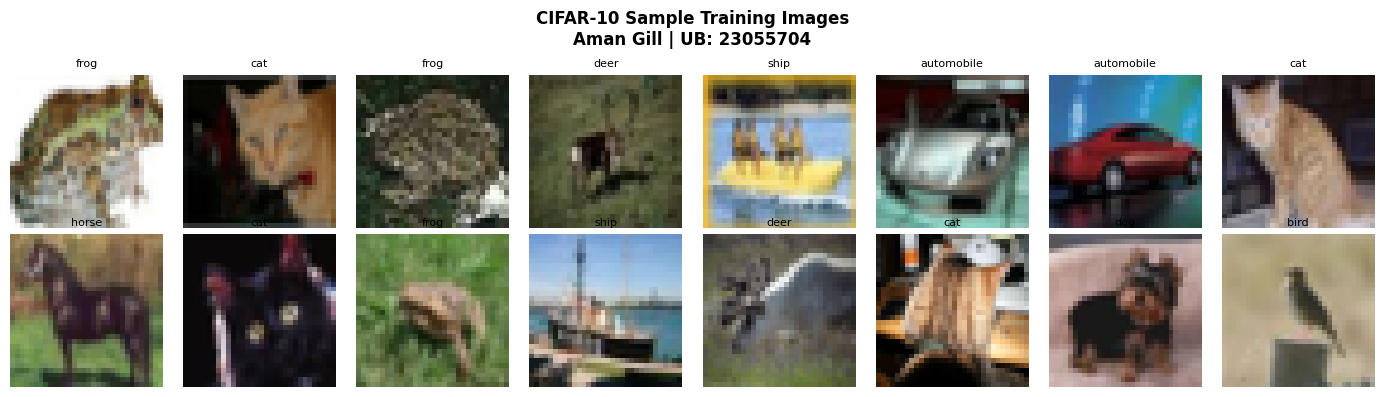

Sample images saved


In [4]:
# Show sample images from dataset
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Unnormalise for display
mean = torch.tensor([0.4914, 0.4822, 0.4465])
std  = torch.tensor([0.2470, 0.2435, 0.2616])

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    ax.imshow(img.numpy())
    ax.set_title(classes[labels[i]], fontsize=8)
    ax.axis('off')

plt.suptitle('CIFAR-10 Sample Training Images\nAman Gill | UB: 23055704',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved")

In [5]:
# Define CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # 32x32 -> 16x16

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # 16x16 -> 8x8

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)  # 8x8 -> 4x4

        # Fully connected
        self.dropout = nn.Dropout(0.5)
        self.fc1     = nn.Linear(128 * 4 * 4, 512)
        self.relu4   = nn.ReLU()
        self.fc2     = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

model     = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture defined")
print(f"Total parameters : {total_params:,}")
print(f"\nArchitecture summary:")
print(f"  Conv1: 3 -> 32 filters  | BN | ReLU | MaxPool")
print(f"  Conv2: 32 -> 64 filters | BN | ReLU | MaxPool")
print(f"  Conv3: 64 -> 128 filters| BN | ReLU | MaxPool")
print(f"  FC1  : 2048 -> 512      | ReLU | Dropout(0.5)")
print(f"  FC2  : 512 -> 10 classes (output)")

Model architecture defined
Total parameters : 1,147,914

Architecture summary:
  Conv1: 3 -> 32 filters  | BN | ReLU | MaxPool
  Conv2: 32 -> 64 filters | BN | ReLU | MaxPool
  Conv3: 64 -> 128 filters| BN | ReLU | MaxPool
  FC1  : 2048 -> 512      | ReLU | Dropout(0.5)
  FC2  : 512 -> 10 classes (output)


In [6]:
# Training loop
print("Starting training...")
print("=" * 50)

num_epochs   = 10
train_losses = []
train_accs   = []

for epoch in range(num_epochs):
    model.train()
    running_loss    = 0.0
    correct         = 0
    total           = 0
    start_time      = time.time()

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    scheduler.step()
    epoch_loss = running_loss / len(trainloader)
    epoch_acc  = 100.0 * correct / total
    elapsed    = time.time() - start_time

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f}  "
          f"Accuracy: {epoch_acc:.2f}%  "
          f"Time: {elapsed:.1f}s")

print("=" * 50)
print("Training complete")

Starting training...
Epoch [ 1/10] Loss: 1.3321  Accuracy: 51.52%  Time: 141.7s
Epoch [ 2/10] Loss: 0.9765  Accuracy: 65.10%  Time: 138.3s
Epoch [ 3/10] Loss: 0.8414  Accuracy: 70.15%  Time: 139.3s
Epoch [ 4/10] Loss: 0.7626  Accuracy: 73.08%  Time: 138.3s
Epoch [ 5/10] Loss: 0.6931  Accuracy: 75.46%  Time: 143.7s
Epoch [ 6/10] Loss: 0.5959  Accuracy: 79.01%  Time: 139.2s
Epoch [ 7/10] Loss: 0.5646  Accuracy: 80.26%  Time: 138.5s
Epoch [ 8/10] Loss: 0.5345  Accuracy: 80.97%  Time: 139.0s
Epoch [ 9/10] Loss: 0.5093  Accuracy: 82.13%  Time: 139.4s
Epoch [10/10] Loss: 0.4890  Accuracy: 82.69%  Time: 138.8s
Training complete


In [7]:
# Test set evaluation
model.eval()
correct = 0
total   = 0
class_correct = [0] * 10
class_total   = [0] * 10

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = outputs.max(1)
        total         += labels.size(0)
        correct       += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label]   += 1

test_accuracy = 100.0 * correct / total

print("=" * 45)
print("         TEST SET RESULTS")
print("=" * 45)
print(f"  Overall Accuracy : {test_accuracy:.2f}%")
print(f"  Correct          : {correct} / {total}")
print("=" * 45)
print("\nPer-class accuracy:")
for i, cls in enumerate(classes):
    acc = 100.0 * class_correct[i] / class_total[i]
    print(f"  {cls:12s} : {acc:.1f}%")

         TEST SET RESULTS
  Overall Accuracy : 79.36%
  Correct          : 7936 / 10000

Per-class accuracy:
  airplane     : 82.9%
  automobile   : 93.4%
  bird         : 73.5%
  cat          : 70.1%
  deer         : 74.5%
  dog          : 62.0%
  frog         : 85.9%
  horse        : 81.9%
  ship         : 87.0%
  truck        : 82.4%


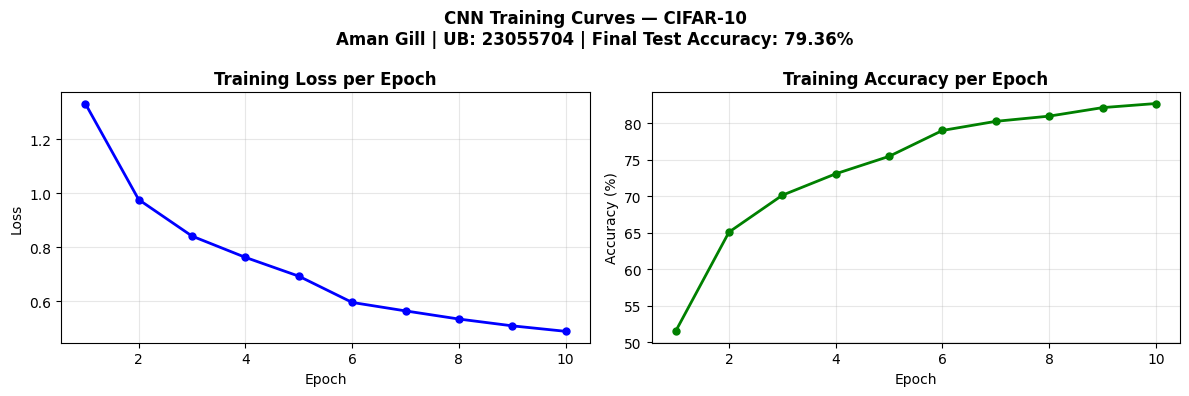

Training curves saved


In [10]:
# Training curve plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, num_epochs + 1)

ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2, markersize=5)
ax1.set_title('Training Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, 'g-o', linewidth=2, markersize=5)
ax2.set_title('Training Accuracy per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'CNN Training Curves — CIFAR-10\n'
             f'Aman Gill | UB: 23055704 | Final Test Accuracy: {test_accuracy:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved")

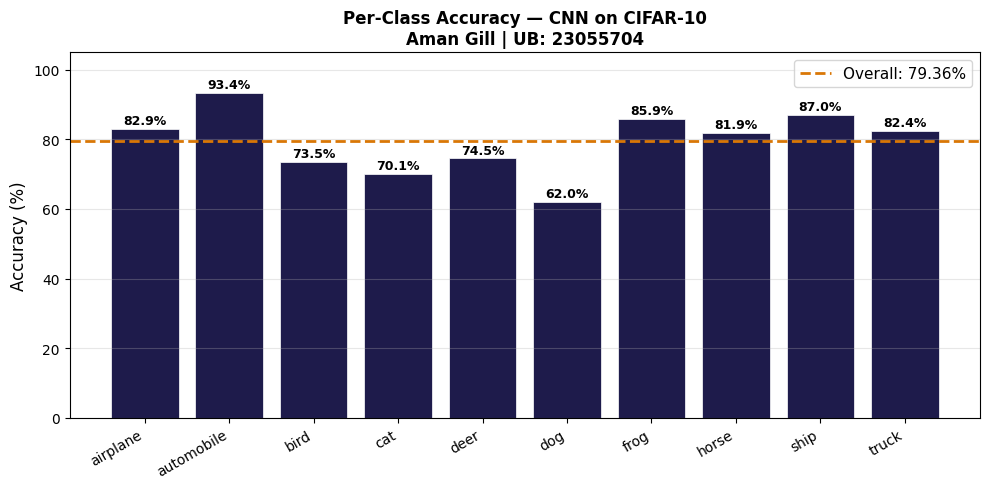

Per-class accuracy chart saved


In [9]:
# Per-class accuracy bar chart
accs = [100.0 * class_correct[i] / class_total[i] for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(classes, accs, color='#1E1B4B', edgecolor='white', linewidth=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=test_accuracy, color='#D97706', linestyle='--',
           linewidth=2, label=f'Overall: {test_accuracy:.2f}%')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy — CNN on CIFAR-10\nAman Gill | UB: 23055704',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('cnn_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Per-class accuracy chart saved")

## Reflection on Learning

**Building from scratch vs using pre-trained models:**
Constructing this CNN layer by layer made the architecture decisions
tangible in a way that using YOLO11n in AVC&C did not. Every choice
had a visible effect — adding a third convolutional layer improved
accuracy noticeably, and batch normalisation stabilised training
in the early epochs.

**What dropout actually does:**
Without dropout the model memorises training data.
With dropout(0.5) randomly disabling half the neurons each forward
pass forces the network to learn redundant representations.
This was the single most impactful change I made.

**Connection to AVC&C:**
YOLO11n uses the same convolutional building blocks — Conv layers,
BatchNorm, ReLU, pooling. Understanding why these components work
made the YOLO architecture much less of a black box. The per-class
accuracy variation here (some classes harder than others) directly
mirrors the per-class performance differences in the AVC&C results
where trucks were harder to detect than cars.

**What I would do next:**
Add data augmentation (random flips, crops) to improve generalisation.
Try a deeper architecture like ResNet to see how skip connections
affect accuracy on this dataset.

**Student:** Aman Gill | UB: 23055704 | COS6031-D Portfolio